<div style="background:#111A33;border-radius:14px;padding:26px 30px;border-left:6px solid #E5484D">
<div style="color:#F5A623;font-size:13px;letter-spacing:3px;font-weight:700">SESSION 10 &nbsp;&middot;&nbsp; WEEK 5 &nbsp;&middot;&nbsp; SQL FUNDAMENTALS</div>
<div style="color:#FFFFFF;font-size:34px;font-weight:800;line-height:1.15;margin-top:8px">Advanced SQL</div>
<div style="color:#C7CEDB;font-size:16px;margin-top:6px">JOINs &middot; Subqueries &middot; CTEs &middot; Window Functions</div>
<div style="background:#F5A623;color:#111A33;display:inline-block;padding:5px 14px;border-radius:6px;font-weight:700;font-size:12px;letter-spacing:1px;margin-top:16px">MODERN DATA ENGINEERING &nbsp;|&nbsp; DEPTHWARE</div>
</div>

### Where we left off

Last session you learned to interrogate **one table at a time**. But you kept hitting a wall: you could group rides by `driver_id`, but never show the driver's **name**. You could count rides, but never *per city*. Those answers live in **other tables**.

Today we knock that wall down. You'll learn to **connect tables** with JOINs, nest one query inside another with **subqueries**, make complex queries readable with **CTEs**, and finally — the power tool of analytical SQL — **window functions**.

> **Prereqs:** Session 9 (SELECT, WHERE, GROUP BY, HAVING, ORDER BY). We build directly on it, and on the same dataset.

---
## 1 &middot; Setup — same four tables as last time

Identical loading step to Session 9. Same data, same `q()` helper.

In [71]:
import duckdb
import pandas as pd
pd.set_option("display.max_rows", 20)

con = duckdb.connect()
for table in ["cities", "drivers", "riders", "rides"]:
    con.sql(f"""
        CREATE TABLE {table} AS
        SELECT * FROM read_csv('data/{table}.csv', header = true)
    """)

def q(sql):
    """Run a SQL string and return a pandas DataFrame."""
    return con.sql(sql).df()

print("Tables:", [r[0] for r in con.sql("SHOW TABLES").fetchall()])

Tables: ['cities', 'drivers', 'riders', 'rides']


---
## 2 &middot; JOINs — connecting tables by a shared key

Our `rides` table stores a `driver_id`, not a driver name. The name lives in `drivers`. A **JOIN** stitches them together: for each ride, it looks up the matching driver by the shared key and brings that driver's columns alongside.
<p align="center">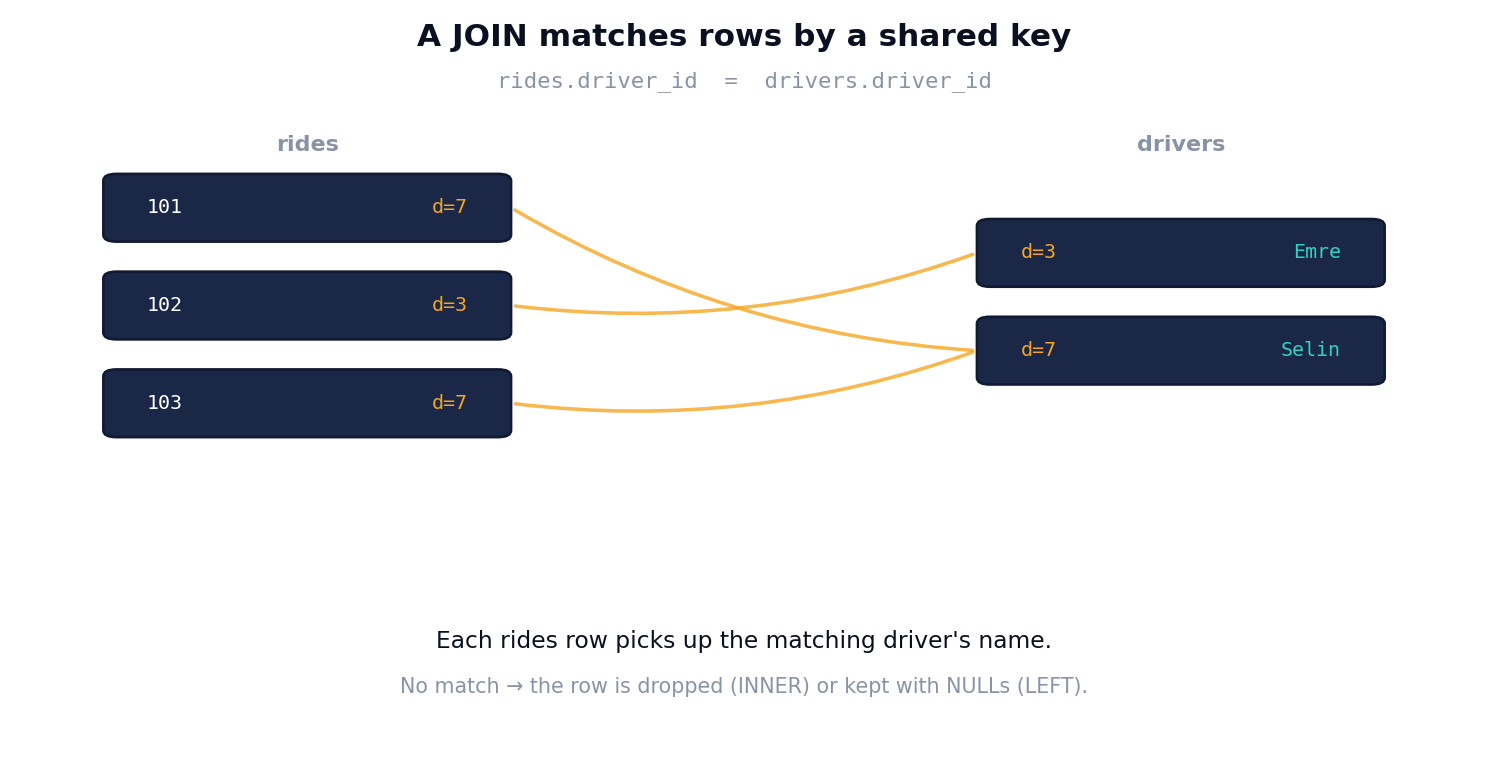</p>

The shared key here is `driver_id`: it's the **primary key** in `drivers` (one row per driver) and a **foreign key** in `rides` (every ride points at one driver). You tell SQL how to match with `ON`:

```sql
FROM rides r
JOIN drivers d ON r.driver_id = d.driver_id
```

Those short letters (`r`, `d`) are **table aliases** — they save typing and make it clear which table each column comes from.

### 2.1 &middot; `INNER JOIN` — keep only matches

The plain `JOIN` (short for `INNER JOIN`) keeps a row **only if the key matches on both sides**. Now we can finally see driver names next to their rides:

In [74]:
# Each ride, now WITH the driver's name and vehicle type.
q("""
    SELECT r.ride_id,
           d.name AS driver_name,
           d.vehicle_type,
           r.fare
    FROM rides r
    JOIN drivers d ON r.driver_id = d.driver_id
    WHERE r.status = 'completed'
    ORDER BY r.fare DESC
    LIMIT 15
""")

,ride_id,driver_name,vehicle_type,fare
0,876,Melis Yilmaz,xl,577.68
1,373,Buse Kurt,xl,575.15
2,890,Kaan Ozkan,xl,570.00
3,589,Melis Yilmaz,xl,562.87
4,1030,Buse Aslan,xl,554.31
5,654,Melis Yilmaz,xl,554.27
6,495,Buse Kurt,xl,551.11
7,1053,Gizem Yilmaz,xl,550.43
8,306,Buse Kurt,xl,549.85
9,845,Gizem Yilmaz,xl,549.34


And the question Session 9 *couldn't* answer — **revenue per driver, by name** — is now one GROUP BY away:

In [75]:
# Top earners, by name this time (join + group by together).
q("""
    SELECT d.name AS driver,
           d.vehicle_type,
           COUNT(*)            AS rides,
           ROUND(SUM(r.fare),0) AS revenue
    FROM rides r
    JOIN drivers d ON r.driver_id = d.driver_id
    WHERE r.status = 'completed'
    GROUP BY d.name, d.vehicle_type
    ORDER BY revenue DESC
    LIMIT 6
""")

,driver,vehicle_type,rides,revenue
0,Gizem Yilmaz,xl,33,10845.0
1,Buse Aslan,xl,23,8494.0
2,Elif Sahin,economy,47,8391.0
3,Emre Sahin,comfort,31,7495.0
4,Selim Yilmaz,comfort,24,7175.0
5,Kaan Ozdemir,comfort,27,6521.0


### 2.2 &middot; `LEFT JOIN` — keep everything on the left, even without a match

`INNER JOIN` silently **drops** rows that don't match. Sometimes that loss is exactly what you *don't* want. Suppose we ask: *which riders have never taken a ride?* An inner join can't answer that — riders with no rides have nothing to match, so they vanish.

`LEFT JOIN` keeps **every row from the left table**, and fills the right side with `NULL` where there's no match. That `NULL` is the signal we're looking for:

In [91]:
q("""
    SELECT ri.rider_id,
           ri.name,
           r.ride_id
    FROM riders ri
    RIGHT JOIN rides r ON ri.rider_id = r.rider_id
    WHERE ri.rider_id IS NULL
    ORDER BY ri.rider_id
""")

,rider_id,name,ride_id


In [87]:
# Riders who have NEVER ridden: LEFT JOIN, then keep the NULL matches.
q("""
    SELECT ri.rider_id,
           ri.name,
           COUNT(r.ride_id) AS rides_taken
    FROM riders ri
    LEFT JOIN rides r ON ri.rider_id = r.rider_id
    GROUP BY ri.rider_id, ri.name
    HAVING COUNT(r.ride_id) = 0
    ORDER BY ri.rider_id
""")

,rider_id,name,rides_taken
0,96,Cem Demir,0
1,97,Kerem Arslan,0
2,98,Sila Kaya,0
3,99,Aylin Demir,0
4,100,Ahmet Cetin,0


Five riders signed up but never rode. With an `INNER JOIN` they'd be invisible — the classic bug where *"the numbers don't add up"* because rows quietly disappeared. **Reach for `LEFT JOIN` whenever the absence of a match is itself meaningful.**

> `RIGHT JOIN` is the mirror image (keep everything on the *right*), and `FULL JOIN` keeps unmatched rows from *both* sides. They're far rarer in practice — you can almost always rewrite a `RIGHT JOIN` as a `LEFT JOIN` by swapping the table order, which most people find easier to read.

### 2.3 &middot; Joining more than two tables

Joins chain. To get **revenue per city**, we hop `rides` &rarr; `riders` (who rode) &rarr; `cities` (where they're based) — two joins in one query:

In [92]:
# Revenue per city: rides -> riders -> cities.
q("""
    SELECT c.city_name,
           c.region,
           COUNT(*)             AS rides,
           ROUND(SUM(r.fare),0) AS revenue
    FROM rides r
    JOIN riders ri ON r.rider_id = ri.rider_id
    JOIN cities c  ON ri.city_id = c.city_id
    WHERE r.status = 'completed'
    GROUP BY c.city_name, c.region
    ORDER BY revenue DESC
""")

,city_name,region,rides,revenue
0,Izmir,Aegean,227,51980.0
1,Istanbul,Marmara,216,48611.0
2,Ankara,Central Anatolia,210,46739.0
3,Antalya,Mediterranean,196,43378.0
4,Bursa,Marmara,191,41061.0


That's the payoff of the whole session arc: a question about *cities* answered from a table of *rides*, by walking the keys between them.

---
## 3 &middot; Subqueries — a query inside a query

A **subquery** is a `SELECT` wrapped in parentheses and used inside another query. The most common use: compare each row against a value you have to *compute first*.

Example: *which completed rides cost more than the average fare?* You don't know the average up front — so you compute it with an inner query, and the outer query compares against it:

In [94]:
q("""
SELECT AVG(fare) FROM rides WHERE status = 'completed'
  """)

,avg(fare)
0,223.533643


In [93]:
# Rides priced above the overall average completed fare.
q("""
    SELECT ride_id, distance_km, fare
    FROM rides
    WHERE status = 'completed'
      AND fare > (SELECT AVG(fare) FROM rides WHERE status = 'completed')
    ORDER BY fare DESC
    LIMIT 5
""")

,ride_id,distance_km,fare
0,876,31.8,577.68
1,373,31.9,575.15
2,890,31.1,570.00
3,589,31.5,562.87
4,1030,30.5,554.31


The inner query `(SELECT AVG(fare) ...)` runs first and produces a single number; the outer `WHERE` then compares every ride's fare against it.

A subquery can also stand in for a **table** in the `FROM` clause — query the *result* of another query. Here we first summarise per driver, then filter that summary:

In [95]:
# Subquery in FROM: build a per-driver summary, then query it.
q("""
    SELECT *
    FROM (
        SELECT driver_id,
               COUNT(*)            AS rides,
               ROUND(SUM(fare),0)  AS revenue
        FROM rides
        WHERE status = 'completed'
        GROUP BY driver_id
    ) AS driver_summary
    WHERE revenue > 6000
    ORDER BY revenue DESC
""")

,driver_id,rides,revenue
0,29,33,10845.0
1,14,23,8494.0
2,21,31,7495.0
3,37,24,7175.0
4,33,27,6521.0
5,50,29,6487.0
6,7,22,6251.0
7,15,23,6167.0
8,32,24,6155.0
9,47,18,6051.0


---
## 4 &middot; CTEs — the same idea, but readable

That nested subquery works, but it's awkward to read — you parse it inside-out. A **Common Table Expression (CTE)**, written with `WITH`, lets you name a query and then use that name like a table. Same result, read top-to-bottom:

In [96]:
# Identical logic to the subquery above, rewritten as a CTE.
q("""
    WITH driver_summary AS (
        SELECT driver_id,
               COUNT(*)            AS rides,
               ROUND(SUM(fare),0)  AS revenue
        FROM rides
        WHERE status = 'completed'
        GROUP BY driver_id
    )
    SELECT *
    FROM driver_summary
    WHERE revenue > 6000
    ORDER BY revenue DESC
""")

,driver_id,rides,revenue
0,29,33,10845.0
1,14,23,8494.0
2,21,31,7495.0
3,37,24,7175.0
4,33,27,6521.0
5,50,29,6487.0
6,7,22,6251.0
7,15,23,6167.0
8,32,24,6155.0
9,47,18,6051.0


Read it as: *"build `driver_summary` first, then select from it."* It's the same query plan as the subquery — but for anything beyond a one-liner, CTEs are dramatically easier to read, debug, and stack. You'll lean on them constantly in the dbt module later in the course. You can even define several CTEs in one `WITH`, separated by commas, each building on the last.

---
## 5 &middot; Window functions — the analytical power tool

This is the one section to slow down on. Window functions are the single most useful "advanced" SQL feature — and the one beginners find most slippery. Take it gently.

Start from what you know. **`GROUP BY` collapses** many rows into one summary row per group — and in doing so, it *throws away the individual rows*. A **window function** computes a similar aggregate, but **keeps every original row** and adds the result as a new column alongside.
<p align="center">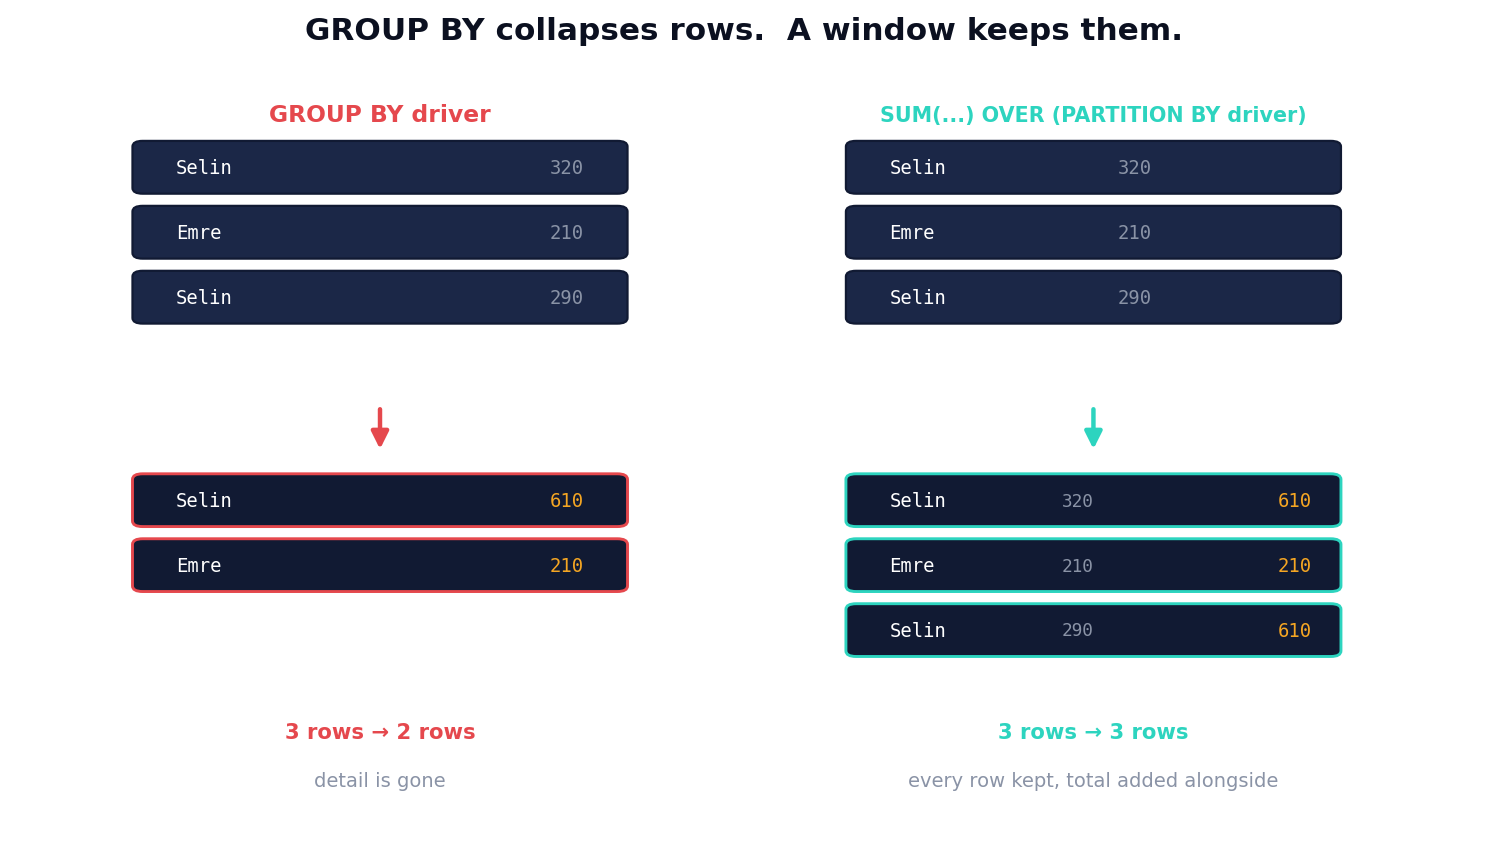</p>

Look at the two sides. Both compute Selin's total of 610. But `GROUP BY` gives you back **2 rows** (one per driver, detail gone), while the window gives you back **all 3 rows** with 610 attached to each of Selin's. That ability — *"keep the detail AND see the group total next to it"* — is what makes windows special.

The syntax is an aggregate (or a ranking function) followed by **`OVER (...)`**. The `OVER` clause defines the "window" of rows to look at:

```sql
SUM(fare) OVER (PARTITION BY driver_id)   -- total per driver, on every row
```

`PARTITION BY` is *like* `GROUP BY` — it splits rows into groups — but it doesn't collapse them.

**So what IS "the window"?** It's the **set of rows the function is allowed to look at** when it computes a value for the current row. A way to picture it: imagine SQL standing on each row in turn and asking *"which other rows count as my neighbors here?"* The `OVER (...)` clause is the answer:

| `OVER (...)` clause | The window for each row |
|---|---|
| `OVER ()` | every row in the result — one big window |
| `OVER (PARTITION BY x)` | only rows with the same `x` |
| `OVER (ORDER BY x)` | all rows, but sorted — needed when *position* or *sequence* matters |
| `OVER (PARTITION BY x ORDER BY y)` | grouped *and* ordered within each group |

Once *"the window is who counts as my neighbors"* clicks, the rest of this section stops feeling magical.

### 5.1 &middot; Ranking: `ROW_NUMBER`, `RANK`, `DENSE_RANK`

The most popular window functions rank rows. Here we rank drivers by revenue. Note there's no row collapsing beyond the GROUP BY we already do — the window adds the rank column:

In [108]:
# Rank drivers by total revenue. ROW_NUMBER gives a unique 1,2,3,...
q("""
    WITH driver_rev AS (
        SELECT 
         driver_id, 
         ROUND(SUM(fare),0) AS revenue
        FROM rides WHERE status = 'completed'
        GROUP BY driver_id
    )
    SELECT driver_id,
           revenue,
           ROW_NUMBER() OVER (ORDER BY revenue DESC) AS row_number,
           RANK() OVER (ORDER BY revenue DESC) AS rank,
           DENSE_RANK() OVER (ORDER BY revenue DESC) AS dense_rank,
    FROM driver_rev
    ORDER BY row_number
    LIMIT 5
""")

,driver_id,revenue,row_number,rank,dense_rank
0,29,10845.0,1,1,1
1,14,8494.0,2,2,2
2,21,7495.0,3,3,3
3,37,7175.0,4,4,4
4,33,6521.0,5,5,5


In [106]:
q("""
    WITH scores(name, score) AS (
        VALUES ('Selin',  95),
               ('Emre',   95),
               ('Yusuf',  90),
               ('Zeynep', 90),
               ('Buse',   85)
    )
    SELECT name,
           score,
           ROW_NUMBER() OVER (ORDER BY score DESC) AS row_number,
           RANK()       OVER (ORDER BY score DESC) AS rank,
           DENSE_RANK() OVER (ORDER BY score DESC) AS dense_rank
    FROM scores
    ORDER BY row_number
""")

,name,score,row_number,rank,dense_rank
0,Selin,95,1,1,1
1,Emre,95,2,1,1
2,Yusuf,90,3,3,2
3,Zeynep,90,4,3,2
4,Buse,85,5,5,3


The three ranking functions differ only in how they handle **ties**:
- **`ROW_NUMBER()`** — always unique: 1, 2, 3, 4 (ties broken arbitrarily)
- **`RANK()`** — ties share a rank, then it *skips*: 1, 2, 2, **4**
- **`DENSE_RANK()`** — ties share a rank, *no skip*: 1, 2, 2, **3**

**Two things worth noticing in the syntax above.**

The parentheses after `ROW_NUMBER`, `RANK`, and `DENSE_RANK` are **always empty**. These functions don't operate on a column value — they just *number rows*, so there's nothing to put inside. (The one exception is `NTILE(n)`, which needs to know how many buckets you want.)

There are also **two `ORDER BY` clauses** in that query, doing two completely different jobs:

- `OVER (ORDER BY revenue DESC)` — tells the window function *how to assign the numbers* (top revenue gets 1)
- the trailing `ORDER BY rank` — tells the database *how to display the final output*

They're often related, but they are *not* the same thing. Forget the one inside `OVER` and your ranks come out looking random.

### 5.2 &middot; `PARTITION BY`: ranking *within* each group

Add `PARTITION BY` and the ranking **restarts for each group**. Here: the top 2 earning drivers *within each vehicle type* — a "top N per group" query, which is genuinely hard without windows:

In [109]:
q("""       
SELECT d.driver_id, d.name, d.vehicle_type,
               ROUND(SUM(r.fare),0) AS revenue
        FROM rides r
        JOIN drivers d ON r.driver_id = d.driver_id
        WHERE r.status = 'completed'
        GROUP BY d.driver_id, d.name, d.vehicle_type
  """)

,driver_id,name,vehicle_type,revenue
0,14,Buse Aslan,xl,8494.0
1,16,Selim Kaya,economy,2039.0
2,28,Kaan Ozkan,xl,5936.0
3,41,Esra Ozturk,economy,4986.0
4,47,Melis Yilmaz,xl,6051.0
...,...,...,...,...
45,18,Buse Celik,economy,2719.0
46,50,Buse Arslan,comfort,6487.0
47,23,Buse Kurt,xl,4546.0
48,39,Gizem Ozturk,economy,2524.0


In [118]:
q("""
    WITH driver_rev AS (
        SELECT d.driver_id, d.name, d.vehicle_type,
               ROUND(SUM(r.fare),0) AS revenue
        FROM rides r
        JOIN drivers d ON r.driver_id = d.driver_id
        WHERE r.status = 'completed'
        GROUP BY d.driver_id, d.name, d.vehicle_type
    )
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY vehicle_type
                   ORDER BY revenue DESC
               ) AS rank_in_type
        FROM driver_rev
        
  """).to_csv("rides_rank.csv")

In [119]:
# Top 2 earners WITHIN each vehicle type.
q("""
    WITH driver_rev AS (
        SELECT d.driver_id, d.name, d.vehicle_type,
               ROUND(SUM(r.fare),0) AS revenue
        FROM rides r
        JOIN drivers d ON r.driver_id = d.driver_id
        WHERE r.status = 'completed'
        GROUP BY d.driver_id, d.name, d.vehicle_type
    ),
    ranked AS (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY vehicle_type
                   ORDER BY revenue DESC
               ) AS rank_in_type
        FROM driver_rev
    )
    SELECT vehicle_type, name, revenue, rank_in_type
    FROM ranked
    WHERE rank_in_type <= 2
    ORDER BY vehicle_type, rank_in_type
""")

,vehicle_type,name,revenue,rank_in_type
0,comfort,Emre Sahin,7495.0,1
1,comfort,Selim Yilmaz,7175.0,2
2,economy,Derya Yildiz,5623.0,1
3,economy,Sila Simsek,5197.0,2
4,xl,Gizem Yilmaz,10845.0,1
5,xl,Buse Aslan,8494.0,2


### 5.3 &middot; Aggregates over a window — group totals on every row

The diagram above showed this exact pattern: each Selin row got stamped with **610**, the group total, while every individual row stayed. In SQL: a plain aggregate (`SUM`, `AVG`, `COUNT`, ...) plus `OVER (PARTITION BY ...)` — and crucially, **no `ORDER BY` inside `OVER`**.

In [ ]:
# Each ride alongside its driver's grand total revenue.
q("""
    SELECT ride_id,
           driver_id,
           fare,
           ROUND(SUM(fare) OVER (PARTITION BY driver_id), 0) AS driver_total
    FROM rides
    WHERE status = 'completed'
      AND driver_id IN (29, 14)
    ORDER BY ride_date
    LIMIT 10
""")

Driver 29's total (10845, our top earner) is stamped on every one of their rides; driver 14's total (8494) on every one of theirs. The individual detail is all still there — that's what makes a window aggregate fundamentally different from `GROUP BY`.

> **The trap to know about.** Adding `ORDER BY` to a `SUM`/`AVG`/`COUNT` over a partition *silently* changes the meaning — from "group total stamped on every row" to "**cumulative** value up to this row." Same function, completely different output:
>
> ```sql
> SUM(fare) OVER (PARTITION BY driver_id)                       -- driver's total (same on every row)
> SUM(fare) OVER (PARTITION BY driver_id ORDER BY ride_date)    -- running total (grows row by row)
> ```
>
> A lot of *"why are my numbers wrong?"* debugging sessions come from someone adding an `ORDER BY` thinking it was just for display.

### 5.4 &middot; Running totals — what happens when you ADD `ORDER BY`

Slip an `ORDER BY` *inside* the `OVER` clause and that aggregate accumulates **row by row**. Here, cumulative daily revenue over time:

In [ ]:
# Daily revenue and a running (cumulative) total.
q("""
    SELECT ride_date,
           driver_id,
           fare,
           ROUND(SUM(fare) OVER (PARTITION BY driver_id), 0) AS driver_total,
           ROUND(SUM(fare) OVER (PARTITION BY driver_id ORDER BY ride_date, ride_id), 0) AS running_total
    FROM rides
    WHERE status = 'completed'
    AND driver_id IN (21,35)
    AND ride_date IN ('2025-01-01', '2025-01-02', 
  '2025-01-03', '2025-01-05', '2025-01-09', '2025-01-10')
    ORDER BY ride_date, driver_id, ride_id
    LIMIT 18
""")

In [ ]:
q("""

  SELECT ride_date, driver_id
  FROM rides
  WHERE driver_id in (29,21,45)
  order by driver_id, ride_date
  
""")

### 5.5 &middot; Looking at neighbouring rows: `LAG` and `LEAD`

`LAG` peeks at the **previous** row, `LEAD` at the **next** one. Perfect for "how did this compare to the day before?" Here we compute the day-over-day change in revenue:

In [ ]:
# Day-over-day change: today's revenue minus yesterday's (LAG).
q("""
    WITH daily AS (
        SELECT ride_date, ROUND(SUM(fare),0) AS revenue
        FROM rides WHERE status = 'completed'
        GROUP BY ride_date
    )
    SELECT ride_date,
           revenue,
           LAG(revenue) OVER (ORDER BY ride_date)             AS prev_day,
           revenue - LAG(revenue) OVER (ORDER BY ride_date)   AS prev_day_change,
           LEAD(revenue) OVER (ORDER BY ride_date)            AS next_day,
           LEAD(revenue) OVER (ORDER BY ride_date) - revenue  AS next_day_change,
    FROM daily
    ORDER BY ride_date
    LIMIT 7
""")

The first row's `prev_day` is `NULL` — there's no day before it. That's expected, and worth pointing out to students before they think it's a bug.

---
## 6 &middot; Putting it all together

One query that uses **a CTE, a join, an aggregate, and a window function** — the shape of real analytical SQL. *For each city, find its single highest-earning driver.*

In [ ]:
# Highest-earning driver in each city — CTE + joins + window, together.
q("""
    WITH city_driver_rev AS (
        SELECT c.city_name,
               d.name AS driver,
               ROUND(SUM(r.fare),0) AS revenue
        FROM rides r
        JOIN drivers d ON r.driver_id = d.driver_id
        JOIN cities  c ON d.city_id   = c.city_id
        WHERE r.status = 'completed'
        GROUP BY c.city_name, d.name
    ),
    ranked AS (
        SELECT *,
               RANK() OVER (
                   PARTITION BY city_name
                   ORDER BY revenue DESC
               ) AS rk
        FROM city_driver_rev
    )
    SELECT city_name, driver, revenue
    FROM ranked
    WHERE rk = 1
    ORDER BY revenue DESC
""")

---
## 7 &middot; Quick reference

| Goal | Tool |
|---|---|
| Combine tables, keep only matches | `INNER JOIN ... ON` |
| Combine tables, keep all left rows | `LEFT JOIN ... ON` |
| Compare each row to a computed value | subquery in `WHERE` |
| Use a query's result as a table | subquery in `FROM`, or a **CTE** |
| Name & stack query steps readably | `WITH name AS (...)` (CTE) |
| Group total on every detail row | `SUM(x) OVER (PARTITION BY g)` |
| Rank rows (unique / ties+skip / ties) | `ROW_NUMBER` / `RANK` / `DENSE_RANK` |
| Running / cumulative total | `SUM(x) OVER (ORDER BY t)` |
| Compare to previous / next row | `LAG(x)` / `LEAD(x) OVER (ORDER BY t)` |

**Two traps to remember:** `INNER JOIN` silently drops non-matches (use `LEFT` when absence matters); and window functions **keep** rows while `GROUP BY` **collapses** them.

---
## 8 &middot; Your turn — exercises

Same dataset. Try each before opening the solution.

**Exercise 1 — `INNER JOIN`**
List each completed ride's `ride_id`, the **rider's name**, and the `fare`. Show the 8 most expensive.

<details>
<summary>&#128161; <b>Show solution</b></summary>

```sql
SELECT r.ride_id, ri.name AS rider, r.fare
FROM rides r
JOIN riders ri ON r.rider_id = ri.rider_id
WHERE r.status = 'completed'
ORDER BY r.fare DESC
LIMIT 8
```

_The join key is rider_id this time, linking rides to riders._

</details>

In [ ]:
# Exercise 1 — your query here


**Exercise 2 — `LEFT JOIN`**
List **all five cities** with their number of completed rides — including any city with **zero**. (Hint: start `FROM cities` and LEFT JOIN outward, so a city with no rides still appears.)

<details>
<summary>&#128161; <b>Show solution</b></summary>

```sql
SELECT c.city_name,
       COUNT(r.ride_id) AS rides
FROM cities c
LEFT JOIN riders ri ON c.city_id = ri.city_id
LEFT JOIN rides  r  ON ri.rider_id = r.rider_id
                   AND r.status = 'completed'
GROUP BY c.city_name
ORDER BY rides DESC
```

_All five cities have rides here, but the LEFT JOIN guarantees a zero would still show rather than vanish._

</details>

In [ ]:
# Exercise 2 — your query here


**Exercise 3 — CTE + aggregate**
Using a CTE, find the **average fare per vehicle type** (join `rides` to `drivers`). Which vehicle type is most expensive on average?

<details>
<summary>&#128161; <b>Show solution</b></summary>

```sql
WITH typed AS (
    SELECT d.vehicle_type, r.fare
    FROM rides r
    JOIN drivers d ON r.driver_id = d.driver_id
    WHERE r.status = 'completed'
)
SELECT vehicle_type,
       COUNT(*)           AS rides,
       ROUND(AVG(fare),2) AS avg_fare
FROM typed
GROUP BY vehicle_type
ORDER BY avg_fare DESC
```

_xl should top the list — its fare multiplier is the highest in the data._

</details>

In [ ]:
# Exercise 3 — your query here


**Exercise 4 — window: ranking**
Rank **riders** by their total spend on completed rides. Show the top 10 with their rank, name, and total spent. (CTE to total per rider, then a window to rank.)

<details>
<summary>&#128161; <b>Show solution</b></summary>

```sql
WITH rider_spend AS (
    SELECT ri.name, ROUND(SUM(r.fare),0) AS spent
    FROM rides r
    JOIN riders ri ON r.rider_id = ri.rider_id
    WHERE r.status = 'completed'
    GROUP BY ri.name
)
SELECT ROW_NUMBER() OVER (ORDER BY spent DESC) AS rank,
       name, spent
FROM rider_spend
ORDER BY rank
LIMIT 10
```

_ROW_NUMBER over the per-rider totals gives a clean 1..10 leaderboard._

</details>

In [ ]:
# Exercise 4 — your query here


**Exercise 5 — window: running total (challenge)**
For driver_id **29** (the top earner), list each of their completed rides by date with a **running total** of their fares. (Filter to that driver, then `SUM(fare) OVER (ORDER BY ride_date)`.)

<details>
<summary>&#128161; <b>Show solution</b></summary>

```sql
SELECT ride_date,
       fare,
       SUM(fare) OVER (ORDER BY ride_date, ride_id) AS running_total
FROM rides
WHERE status = 'completed'
  AND driver_id = 29
ORDER BY ride_date, ride_id
```

_The final running_total should match driver 29's grand total of 10845 from the ranking example._

</details>

In [ ]:
# Exercise 5 — your query here


---
## 9 &middot; Recap & what's next

You've now got the full analytical SQL toolkit:

- **JOINs** connect tables by a shared key — `INNER` keeps matches, `LEFT` keeps everything on the left (and reveals what's missing)
- **Subqueries** nest one query in another; **CTEs** (`WITH`) do the same thing far more readably
- **Window functions** keep every row while adding group-level calculations — ranking, running totals, row-to-row comparisons with `LAG`/`LEAD`

This wraps **Week 5 — SQL Fundamentals**. You can now answer genuinely hard questions of a relational dataset, entirely locally.

> **Coming up — Week 6: SQL for Data Transformation.** We push these patterns further (pivots, array operations) and into **query optimization** — why some queries are slow and how to read an execution plan. Everything you wrote here in DuckDB transfers almost unchanged to **BigQuery** in Module 3, where the same SQL runs over data far too big for one machine.

<div style="background:#111A33;border-radius:10px;padding:14px 18px;margin-top:14px;color:#C7CEDB;font-size:13px">
<b style="color:#F5A623">Depthware</b> &nbsp;&middot;&nbsp; Modern Data Engineering &nbsp;&middot;&nbsp; Session 10 — Advanced SQL
</div>